In [1]:
import pandas as pd

df = pd.DataFrame({
    "wafer_id": [
        "W001", "W002", "W003", "W004", "W005",
        "W006", "W007", "W008", "W009", "W010",
        "W011", "W012", "W013", "W014", "W015",
        "W016", "W017", "W018", "W019", "W020"
    ],
    "film_thickness_nm": [
        99.8, 100.4, 100.1, 99.9, 100.2,
        100.0, 100.3, 99.7, 100.1, 100.2,
        100.4, 99.8, 100.0, 100.3, 100.1,
        100.2, 100.4, 100.1, 100.3, 100.2
    ]
})

print(df)

   wafer_id  film_thickness_nm
0      W001               99.8
1      W002              100.4
2      W003              100.1
3      W004               99.9
4      W005              100.2
5      W006              100.0
6      W007              100.3
7      W008               99.7
8      W009              100.1
9      W010              100.2
10     W011              100.4
11     W012               99.8
12     W013              100.0
13     W014              100.3
14     W015              100.1
15     W016              100.2
16     W017              100.4
17     W018              100.1
18     W019              100.3
19     W020              100.2


In [2]:
mean = df["film_thickness_nm"].mean()
std = df["film_thickness_nm"].std()

UCL = mean + 3 * std
LCL = mean - 3 * std

print(f"Mean: {mean:.2f} nm")
print(f"Standard Deviation: {std:.2f} nm")
print(f"Upper Control Limit (UCL): {UCL:.2f} nm")
print(f"Lower Control Limit (LCL): {LCL:.2f} nm")   

Mean: 100.12 nm
Standard Deviation: 0.21 nm
Upper Control Limit (UCL): 100.75 nm
Lower Control Limit (LCL): 99.50 nm


Matplotlib is building the font cache; this may take a moment.


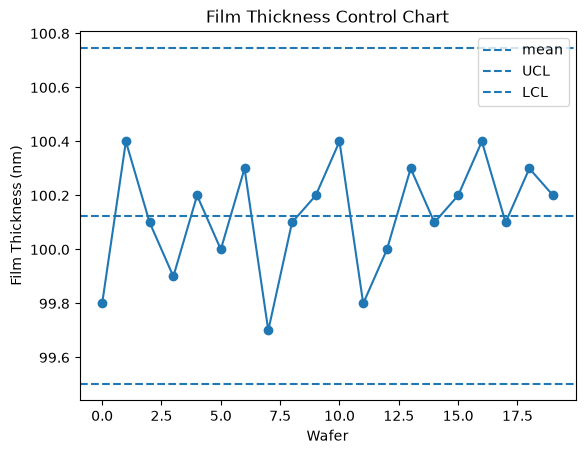

In [3]:
import matplotlib.pyplot as plt

plt.plot(df["film_thickness_nm"], marker="o")

plt.axhline(mean, linestyle="--", label="mean")
plt.axhline(UCL, linestyle="--", label="UCL")
plt.axhline(LCL, linestyle="--", label="LCL")

plt.xlabel("Wafer")
plt.ylabel("Film Thickness (nm)")
plt.title("Film Thickness Control Chart")

plt.legend()
plt.show()


In [4]:
baseline_mean = mean
baseline_UCL = UCL
baseline_LCL = LCL

In [5]:
new_wafers = pd.DataFrame({
    "wafer_id": ["W021", "W022", "W023", "W024", "W025"],
    "film_thickness_nm": [101.0, 101.1, 101.2, 101.0, 101.3]
})

df = pd.concat([df, new_wafers], ignore_index=True)

In [6]:
df["out_of_control"] = (
    (df["film_thickness_nm"] > baseline_UCL) |
    (df["film_thickness_nm"] < baseline_LCL)
)

print(df[df["out_of_control"]])

   wafer_id  film_thickness_nm  out_of_control
20     W021              101.0            True
21     W022              101.1            True
22     W023              101.2            True
23     W024              101.0            True
24     W025              101.3            True


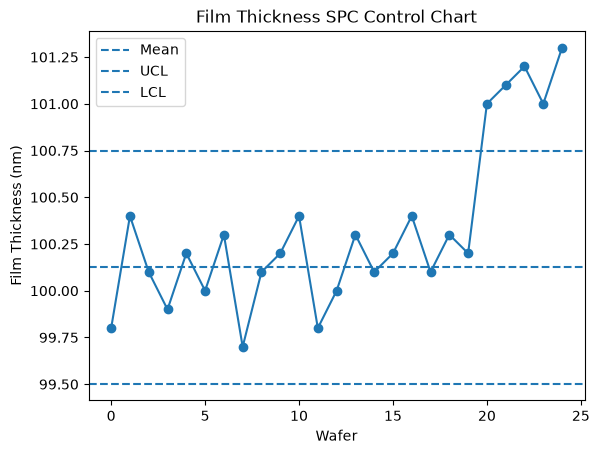

In [7]:
plt.plot(
    df["film_thickness_nm"],
    marker="o"
)

plt.axhline(baseline_mean, linestyle="--", label="Mean")
plt.axhline(baseline_UCL, linestyle="--", label="UCL")
plt.axhline(baseline_LCL, linestyle="--", label="LCL")

plt.xlabel("Wafer")
plt.ylabel("Film Thickness (nm)")
plt.title("Film Thickness SPC Control Chart")

plt.legend()
plt.show()

In [8]:
df["above_mean"] = df["film_thickness_nm"] > baseline_mean

df["five_above_mean"] = df["above_mean"].rolling(window=5).sum() == 5


print(df[df["five_above_mean"]])

   wafer_id  film_thickness_nm  out_of_control  above_mean  five_above_mean
22     W023              101.2            True        True             True
23     W024              101.0            True        True             True
24     W025              101.3            True        True             True


In [9]:
df["below_mean"] = df["film_thickness_nm"] < baseline_mean

df["five_below_mean"] = (
    df["below_mean"]
    .rolling(window=5)
    .sum()
    == 5
)

print(df[df["five_below_mean"]])

Empty DataFrame
Columns: [wafer_id, film_thickness_nm, out_of_control, above_mean, five_above_mean, below_mean, five_below_mean]
Index: []


In [10]:
df["spc_alarm"] = (
    df["out_of_control"] |
    df["five_above_mean"] |
    df["five_below_mean"]
)

print(df[df["spc_alarm"]])

   wafer_id  film_thickness_nm  out_of_control  above_mean  five_above_mean  \
20     W021              101.0            True        True            False   
21     W022              101.1            True        True            False   
22     W023              101.2            True        True             True   
23     W024              101.0            True        True             True   
24     W025              101.3            True        True             True   

    below_mean  five_below_mean  spc_alarm  
20       False            False       True  
21       False            False       True  
22       False            False       True  
23       False            False       True  
24       False            False       True  
